In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [36]:
# Loads historical stock data (e.g., Google stock) from a CSV file into a DataFrame
df = pd.read_csv("./goog1.csv")

In [37]:

# Displays the first few rows of the dataset to understand the structure
df.head()

,Date,Open,High,Low,Close,Volume
0,12/19/2016,790.219971,797.659973,786.270020,794.200012,1225900
1,12/20/2016,796.760010,798.650024,793.270020,796.419983,925100
2,12/21/2016,795.840027,796.676025,787.099976,794.559998,1208700
3,12/22/2016,792.359985,793.320007,788.580017,791.260010,969100
4,12/23/2016,790.900024,792.739990,787.280029,789.909973,623400


In [38]:
df_req = df['Close']


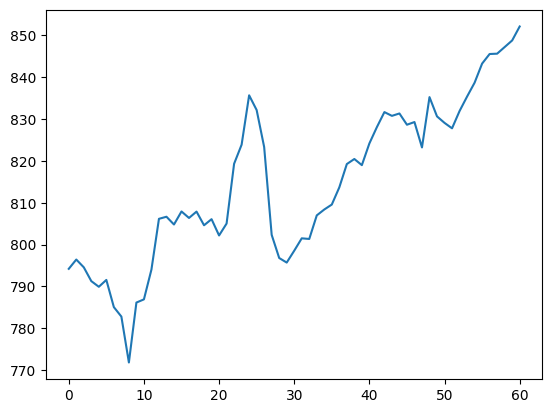

In [39]:
plt.plot(df_req)

In [40]:
from sklearn.preprocessing import MinMaxScaler

# Scales the closing prices to a 0–1 range using MinMaxScaler
scaler = MinMaxScaler()
df_req = scaler.fit_transform(np.array(df_req).reshape(-1,1))    

In [41]:
training_size = int(len(df_req)*0.8)
df_train = df_req[:training_size, :]
df_test = df_req[training_size:len(df_req), :]

In [42]:
def create_dataset(data, step=4):
    X = []
    y = []
    # Create a sequence of 2d array with first 4 as input and next 1 as output and it should run  
    for i in range(len(data)-step):
        X.append(data[i:i+step, :])
        y.append(data[i, :])

    return np.array(X), np.array(y)

x_train, y_train = create_dataset(df_train)
x_test, y_test = create_dataset(df_test)

In [43]:
x_train

array([[[0.27870496],
        [0.30635093],
        [0.28318798],
        [0.24209223]],

       [[0.30635093],
        [0.28318798],
        [0.24209223],
        [0.22527981]],

       [[0.28318798],
        [0.24209223],
        [0.22527981],
        [0.24570341]],

       [[0.24209223],
        [0.22527981],
        [0.24570341],
        [0.16475695]],

       [[0.22527981],
        [0.24570341],
        [0.16475695],
        [0.13661236]],

       [[0.24570341],
        [0.16475695],
        [0.13661236],
        [0.        ]],

       [[0.16475695],
        [0.13661236],
        [0.        ],
        [0.17833138]],

       [[0.13661236],
        [0.        ],
        [0.17833138],
        [0.18779601]],

       [[0.        ],
        [0.17833138],
        [0.18779601],
        [0.27646347]],

       [[0.17833138],
        [0.18779601],
        [0.27646347],
        [0.42752207]],

       [[0.18779601],
        [0.27646347],
        [0.42752207],
        [0.43374872]],

       [[0

In [44]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

# Sequential LSTM model
model = Sequential()
model.add(LSTM(128, return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(LSTM(32))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

C:\Users\saksh\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


##### Trains the LSTM model for 50 epochs.

model.fit(x_train, y_train, epochs=50)

In [46]:
metrics = model.evaluate(x_test, y_test)
metrics

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - loss: 0.0012


0.0011722873896360397

In [47]:


# Predictions (y_pred) and actual values (y_test) are rescaled back to original values using inverse_transform
y_pred = model.predict(x_test)
# y_test = scaler.inverse_transform(y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step


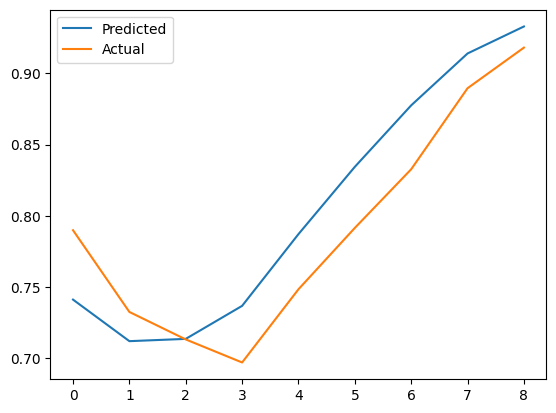

In [48]:
plt.plot(y_pred, label="Predicted")
plt.plot(y_test, label="Actual")
plt.legend()